In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch

# configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

# define global paths and names
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'
TRAIN_PATH = DATASET_PATH + "/train"
VALIDATION_PATH = DATASET_PATH + "/validation"

True


Inspect dataset:

In [3]:
from dataset import ImageDataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = ImageDataset(VALIDATION_PATH, transform)
sample = next(iter(dataset))
print(sample.shape)

torch.Size([3, 64, 64])


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

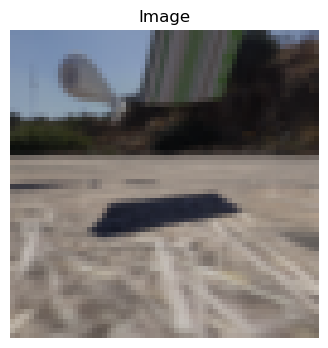

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample.permute(1, 2, 0).numpy())
plt.title("Image")
plt.axis("off")

### Prepare dataset for training an autoencoder

In [5]:
train_dataset = ImageDataset(TRAIN_PATH, transform)
val_dataset = ImageDataset(VALIDATION_PATH, transform)

In [6]:
from torch.utils.data import DataLoader

B_SIZE = 64

train_loader = DataLoader(
        dataset=train_dataset, 
        batch_size=B_SIZE, 
        shuffle=True,
        num_workers=4
) 
val_loader = DataLoader(
        dataset=val_dataset, 
        batch_size=B_SIZE,
        shuffle=False,
        num_workers=4
)

### Define and train an autoencoder

#### Image autoencoder

In [13]:
import torch.nn as nn

class ImageAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: 64x64 → 4x4
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=4, stride=2, padding=1),   # 64x64 → 32x32
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 32x32 → 16x16
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 16x16 → 8x8
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),# 8x8 → 4x4
            nn.ReLU()
        )

        # Decoder: 4x4 → 64x64
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), # 4x4 → 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 8x8 → 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 16x16 → 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),    # 32x32 → 64x64
            nn.Sigmoid()  # [0,1] output
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [16]:
from train import Trainer
from evaluate import evaluate_autoencoder

autoencoder_img = ImageAutoencoder()

In [17]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = torch.optim.Adam(autoencoder_img.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

trainer = Trainer(model=autoencoder_img, evaluate=evaluate_autoencoder,
                  optimizer=optimizer, criterion=criterion, scheduler=scheduler)
trainer.train(train_loader, val_loader, 5)



































































































































































































































































































































































































































































































































































































































































































































































Ep 0 Iter 2236: Loss=0.0018):   0%|          | 0/5 [1:09:11<?, ?it/s]
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7915d8b18360>
Traceback (most recent call last):
  File "/home/user/kellerv1/miniforge3/envs/lab_env/lib/python3.13/

Saved epoch_000_iter_03651's state to experiments/12-31_11-08-2025_ConvAE/checkpoints/epoch_000_iter_03651.pth








































































































































































































































































































































































































































































































































































































































































































































































Ep 0 Iter 2236: Loss=0.0018):   0%|          | 0/5 [1:11:58<?, ?it/s]
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7915d8b18360>
Traceback (most recent call last):
  File "/home/user/kellerv1/miniforge3/envs/lab_env/lib/python3

KeyboardInterrupt: 

##### Inspect reconstruction of a random sample

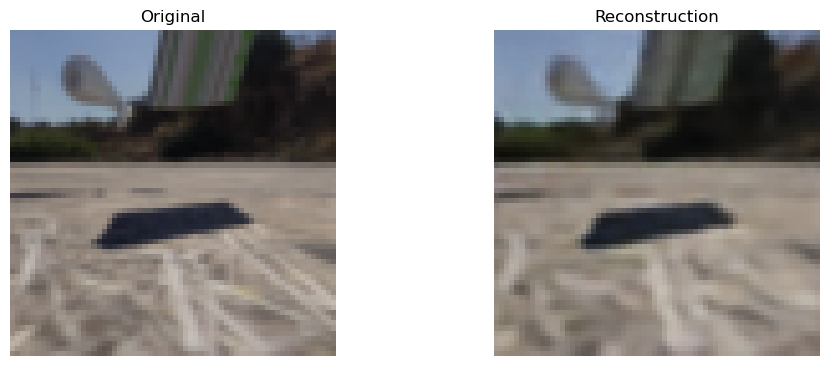

In [10]:
sample = next(iter(val_dataset))['img']
reconstr = autoencoder_img(sample.to(device))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample.permute(1, 2, 0).numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstr.permute(1, 2, 0).detach().cpu().numpy())
plt.title("Reconstruction")
plt.tight_layout()
plt.axis("off")
plt.show()

#### Mask Autoencoder

In [ ]:
# TODO